<a href="https://colab.research.google.com/github/qja0707/OralMedicineImageDetection/blob/docs%2Fgyubeom%2Feda/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA

경구약제 객체 탐지 프로젝트 데이터 분석용 노트북

In [1]:
import kagglehub
import os

# 환경 변수에 토큰 등록 (kaggle 개인 api 토큰. github에 저장하지마세요)
os.environ['KAGGLE_API_TOKEN'] = "KGAT_957ae188e2917ffae289bcff9a2733e5"

# Download latest version
path = kagglehub.competition_download('ai10-level1-project')

print("Path to competition files:", path)

100%|██████████| 1.79G/1.79G [00:13<00:00, 147MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/ai10-level1-project


In [2]:
path = os.path.join(path, 'sprint_ai_project1_data')
print(os.listdir(path))

['test_images', 'train_annotations', 'train_images']


In [3]:
test_images_path = os.path.join(path, 'test_images')

train_images_path = os.path.join(path, 'train_images')

train_annotations_path = os.path.join(path, 'train_annotations')


1. 이미 rotate 증강이 되어있는 것으로 보임
2. 이미지 안에 여러개의 알약이 있는 경우 알약 별로 따로 json 파일이 존재하는것으로 보임 -> 하나의 json 파일로 묶어줄 필요가 있지 않을까?

# 이미지 파일 이름 체크

In [8]:
import re

count = 0

for root, dirs, files in os.walk(train_images_path):
    for file in files:
        count +=1
        # 확장자 제외한 파일명만 추출
        name = os.path.splitext(file)[0]

        name = name.split("_")[0]

        print(name)

        if count > 10:
            break

K-001900-016548-019607-033009
K-003351-016688-041768
K-003351-003832-021325
K-003351-018147-035206
K-002483-012081-012778-025438
K-003351-019232-029667
K-003351-019232-021325
K-003351-013900-036637
K-003351-020014-021325
K-003351-033880-035206
K-003351-016232-019232


In [4]:
import os
import re
from collections import Counter

# 1. 정규표현식 및 초기화
code_extractor = re.compile(r'(?<=K-)\d{6}|(?<=-)\d{6}')
pill_counts = Counter() # 이 자체가 {"code": n} 형태의 맵이 됩니다.
total_files_processed = 0  # 전체 순회 파일 수
failed_files = []          # 정규표현식 매칭 실패 파일 목록

# 2. 순회 및 카운트
for root, dirs, files in os.walk(train_images_path):
    for file in files:
        if file.startswith('.'): continue

        total_files_processed += 1  # 파일 count 증가

        # 파일명 정제 (확장자 제거 후 _ 앞부분만)
        clean_name = os.path.splitext(file)[0].split("_")[0]

        # 코드 추출 및 맵 업데이트
        codes = code_extractor.findall(clean_name)

        if codes:
            pill_counts.update(codes)
        else:
            # 매칭되는 코드가 없는 경우 리스트에 추가
            failed_files.append(file)

# 3. 전체 합계 및 통계 계산
total_pill_count = sum(pill_counts.values())
sorted_pill_map = dict(sorted(pill_counts.items()))

print(f"📊 [알약 데이터셋 전체 통계]")
print(f" - 전체 순회 파일 수: {total_files_processed}개")
print(f" - 총 알약 등장 횟수(Total Sum): {total_pill_count}개")
print(f" - 유니크 알약 종류: {len(sorted_pill_map)}종")
print(f" - 추출 실패 파일 수: {len(failed_files)}개")
print("-" * 45)

# 4. 전체 데이터 출력 (코드 | 빈도 | 퍼센트)
print(f"{'코드':<10} | {'빈도':<8} | {'비중(%)':<10}")
print("-" * 45)

for code, count in sorted_pill_map.items():
    percentage = (count / total_pill_count) * 100
    print(f"{code:<10} | {count:<10} | {percentage:>6.2f}%")


📊 [알약 데이터셋 전체 통계]
 - 전체 순회 파일 수: 232개
 - 총 알약 등장 횟수(Total Sum): 771개
 - 유니크 알약 종류: 56종
 - 추출 실패 파일 수: 0개
---------------------------------------------
코드         | 빈도       | 비중(%)     
---------------------------------------------
001900     | 15         |   1.95%
002483     | 9          |   1.17%
003351     | 157        |  20.36%
003483     | 45         |   5.84%
003544     | 6          |   0.78%
003743     | 3          |   0.39%
003832     | 20         |   2.59%
004543     | 6          |   0.78%
012081     | 3          |   0.39%
012247     | 3          |   0.39%
012778     | 6          |   0.78%
013395     | 3          |   0.39%
013900     | 15         |   1.95%
016232     | 21         |   2.72%
016262     | 23         |   2.98%
016548     | 18         |   2.33%
016551     | 3          |   0.39%
016688     | 8          |   1.04%
018147     | 15         |   1.95%
018357     | 13         |   1.69%
019232     | 17         |   2.20%
019552     | 3          |   0.39%
019607     | 6      

* 전체 이미지 파일 수 : 232개
* 총 경구약제 등장 횟수 : 771개
* 경구약제 종류 : 56종

|코드         | 빈도       | 비중(%)|
|---|---|---|
|001900     | 15         |   1.95%|
|002483     | 9          |   1.17%|
|003351     | 157        |  20.36%|
|003483     | 45         |   5.84%|
|003544     | 6          |   0.78%|
|003743     | 3          |   0.39%|
|003832     | 20         |   2.59%|
|004543     | 6          |   0.78%|
|012081     | 3          |   0.39%|
|012247     | 3          |   0.39%|
|012778     | 6          |   0.78%|
|013395     | 3          |   0.39%|
|013900     | 15         |   1.95%|
|016232     | 21         |   2.72%|
|016262     | 23         |   2.98%|
|016548     | 18         |   2.33%|
|016551     | 3          |   0.39%|
|016688     | 8          |   1.04%|
|018147     | 15         |   1.95%|
|018357     | 13         |   1.69%|
|019232     | 17         |   2.20%|
|019552     | 3          |   0.39%|
|019607     | 6          |   0.78%|
|019861     | 6          |   0.78%|
|020014     | 17         |   2.20%|
|020238     | 20         |   2.59%|
|020877     | 12         |   1.56%|
|021325     | 22         |   2.85%|
|021771     | 3          |   0.39%|
|022074     | 16         |   2.08%|
|022347     | 9          |   1.17%|
|022362     | 3          |   0.39%|
|024850     | 3          |   0.39%|
|025367     | 12         |   1.56%|
|025438     | 6          |   0.78%|
|025469     | 12         |   1.56%|
|027733     | 12         |   1.56%|
|027777     | 3          |   0.39%|
|027926     | 3          |   0.39%|
|027993     | 3          |   0.39%|
|028763     | 9          |   1.17%|
|029345     | 6          |   0.78%|
|029451     | 3          |   0.39%|
|029667     | 18         |   2.33%|
|030308     | 9          |   1.17%|
|031863     | 12         |   1.56%|
|031885     | 3          |   0.39%|
|032310     | 15         |   1.95%|
|033009     | 3          |   0.39%|
|033208     | 3          |   0.39%|
|033880     | 17         |   2.20%|
|034597     | 3          |   0.39%|
|035206     | 37         |   4.80%|
|036637     | 19         |   2.46%|
|038162     | 18         |   2.33%|
|041768     | 16         |   2.08%|

## 이미지 확장자 / 해상도 / 크기 확인

In [5]:
import os
from PIL import Image
from collections import Counter

# 1. 초기화
extensions = Counter()     # 확장자별 개수
resolutions = Counter()    # 해상도(W, H)별 개수
file_sizes = []            # 파일 용량 리스트 (MB 단위)

# 2. 순회 및 분석
for root, dirs, files in os.walk(train_images_path):
    for file in files:
        if file.startswith('.'): continue

        file_path = os.path.join(root, file)

        # 1) 확장자 추출 및 카운트
        ext = os.path.splitext(file)[1].lower()
        extensions[ext] += 1

        # 2) 파일 크기 계산 (Byte -> MB)
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        file_sizes.append(size_mb)

        # 3) 이미지 해상도 추출
        try:
            with Image.open(file_path) as img:
                resolutions[img.size] += 1
        except:
            # 이미지가 아니거나 손상된 파일인 경우
            pass

# 3. 통계 결과 출력
print(f"📊 [파일 기술 통계 분석]")
print("-" * 45)

# 확장자 분포
print(f"✅ 유니크 확장자:")
for ext, count in extensions.items():
    print(f" - {ext if ext else 'No Ext'}: {count}개")

# 해상도 분포 (상위 5개)
print(f"\n✅ 해상도 분포 (가로 x 세로):")
for res, count in resolutions.most_common(5):
    print(f" - {res[0]} x {res[1]}: {count}개")

# 용량 통계
total_size = sum(file_sizes)
avg_size = total_size / len(file_sizes) if file_sizes else 0
print(f"\n✅ 파일 용량 통계:")
print(f" - 전체 합계: {total_size:.2f} MB")
print(f" - 평균 용량: {avg_size:.2f} MB")
print(f" - 최대 용량: {max(file_sizes) if file_sizes else 0:.2f} MB")
print(f" - 최소 용량: {min(file_sizes) if file_sizes else 0:.2f} MB")
print("-" * 45)


📊 [파일 기술 통계 분석]
---------------------------------------------
✅ 유니크 확장자:
 - .png: 232개

✅ 해상도 분포 (가로 x 세로):
 - 976 x 1280: 232개

✅ 파일 용량 통계:
 - 전체 합계: 387.67 MB
 - 평균 용량: 1.67 MB
 - 최대 용량: 1.92 MB
 - 최소 용량: 1.50 MB
---------------------------------------------


In [6]:
import os
import json
from collections import defaultdict


output_dir = './merged_labels'  # 통합된 123.json이 저장될 폴더

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 파일명을 키로 하여 데이터를 모을 딕셔너리
# merged_storage['123.json'] = {'images': [...], 'annotations': [...], 'categories': [...]}
merged_storage = defaultdict(lambda: {"images": [], "annotations": [], "categories": []})

print("🔍 하위 폴더를 돌며 동일 파일명의 JSON 데이터를 수집합니다...")

# 2. 리커시브 순회 및 데이터 수집
for root, dirs, files in os.walk(train_annotations_path):
    for file in files:
        if not file.lower().endswith('.json'):
            continue

        full_path = os.path.join(root, file)

        with open(full_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # 각 키의 데이터를 리스트에 추가 (원래 데이터가 리스트면 extend, 아니면 append)
        for key in ["images", "annotations", "categories"]:
            val = data.get(key, [])
            if isinstance(val, list):
                merged_storage[file][key].extend(val)
            else:
                merged_storage[file][key].append(val)

# 3. 수집된 데이터 파일별 저장
print(f"📦 총 {len(merged_storage)}개의 고유 파일로 통합 중...")

for filename, merged_data in merged_storage.items():
    # 중복 데이터 제거 (필요한 경우) - 특히 categories는 중복이 많을 수 있음
    # 여기서는 요청하신 대로 원본 키값들을 그대로 담는 데 집중합니다.

    output_path = os.path.join(output_dir, filename)
    with open(output_path, 'w', encoding='utf-8') as out_f:
        json.dump(merged_data, out_f, indent=4, ensure_ascii=False)

print(f"✅ 완료! {output_dir} 폴더에 파일별로 통합되었습니다.")


🔍 하위 폴더를 돌며 동일 파일명의 JSON 데이터를 수집합니다...
📦 총 232개의 고유 파일로 통합 중...
✅ 완료! ./merged_labels 폴더에 파일별로 통합되었습니다.


In [7]:
import os
import json



# 통계를 위한 초기화
stats = {
    "images": {"min": float('inf'), "max": 0},
    "annotations": {"min": float('inf'), "max": 0},
    "categories": {"min": float('inf'), "max": 0}
}

file_list = [f for f in os.listdir(output_dir) if f.endswith('.json')]

if not file_list:
    print("❌ 분석할 JSON 파일이 없습니다.")
else:
    for file in file_list:
        with open(os.path.join(output_dir, file), 'r', encoding='utf-8') as f:
            data = json.load(f)

            for key in ["images", "annotations", "categories"]:
                count = len(data.get(key, []))

                if count < stats[key]["min"]:
                    stats[key]["min"] = count
                if count > stats[key]["max"]:
                    stats[key]["max"] = count

    print(f"📊 [통합 JSON 파일별 리스트 개수 통계]")
    print(f" - 분석 파일 수: {len(file_list)}개")
    print("-" * 45)
    print(f"{'항목':<12} | {'Min':<10} | {'Max':<10}")
    print("-" * 45)
    for key in ["images", "annotations", "categories"]:
        print(f"{key:<12} | {stats[key]['min']:<10} | {stats[key]['max']:<10}")



📊 [통합 JSON 파일별 리스트 개수 통계]
 - 분석 파일 수: 232개
---------------------------------------------
항목           | Min        | Max       
---------------------------------------------
images       | 2          | 4         
annotations  | 2          | 4         
categories   | 2          | 4         


In [8]:
# 1. 알약 코드 중심 마스터 딕셔너리 (객체 직결형)
pill_data_master = {}

# 2. 데이터 순회하며 객체에 count 추가 및 마스터 등록
for filename, content in merged_storage.items():
    for img_obj in content.get("images", []):
        # drug_N에서 코드 추출
        drug_n_val = img_obj.get("drug_N", "")
        if '-' in drug_n_val:
            pill_code = drug_n_val.split('-')[1].split('_')[0]

            # 이미 추출된 정보가 있다면 그대로 쓰고, count 키만 추가해서 등록
            # sorted_pill_map에 있는 해당 코드의 빈도수를 삽입
            img_obj['count'] = sorted_pill_map.get(pill_code, 0)

            # 마스터 딕셔너리에 코드별로 객체 매핑
            pill_data_master[pill_code] = img_obj

# 3. 결과 확인
sample_code = list(pill_data_master.keys())[0] if pill_data_master else None
if sample_code:
    print(f"✅ 마스터 딕셔너리 생성 완료! (샘플 코드: {sample_code})")
    print(json.dumps(pill_data_master[sample_code], indent=4, ensure_ascii=False))


✅ 마스터 딕셔너리 생성 완료! (샘플 코드: 016548)
{
    "file_name": "K-001900-016548-024850-029345_0_2_0_2_75_000_200.png",
    "width": 976,
    "height": 1280,
    "imgfile": "K-001900-016548-024850-029345_0_2_0_2_75_000_200.png",
    "drug_N": "K-016548",
    "drug_S": "정상알약",
    "back_color": "연회색 배경",
    "drug_dir": "앞면",
    "light_color": "주백색",
    "camera_la": 75,
    "camera_lo": 0,
    "size": 200,
    "dl_idx": "16548",
    "dl_mapping_code": "K-016548",
    "dl_name": "가바토파정 100mg",
    "dl_name_en": "Gabatopa Tab. 100mg",
    "img_key": null,
    "dl_material": "토피라메이트",
    "dl_material_en": "Topiramate",
    "dl_custom_shape": "정제, 저작정",
    "dl_company": "동아에스티(주)",
    "dl_company_en": "Dong-A St",
    "di_company_mf": "",
    "di_company_mf_en": "",
    "item_seq": 200500251,
    "di_item_permit_date": "20050628",
    "di_class_no": "[01130]항전간제",
    "di_etc_otc_code": "전문의약품",
    "di_edi_code": "642500020,A01508461",
    "chart": null,
    "drug_shape": null,
    "thick": 0,
 

In [11]:
# 1. 무결성 검증 및 통계 계산
table_rows = []
code_check = {}
total_sum = sum(data.get("count", 0) for data in pill_data_master.values()) # 퍼센트 계산용 전체 합계

print(f"{'코드':<10} | {'빈도(개수)':<8} | {'비중(%)':<8} | {'dl_name'}")
print("-" * 70)

for code, data in pill_data_master.items():
    current_dl_name = data.get("dl_name", "Unknown")
    current_count = data.get("count", 0)

    # 퍼센트 계산
    percentage = (current_count / total_sum) * 100 if total_sum > 0 else 0

    # --- [무결성 검사] ---
    if code in code_check:
        if code_check[code] != current_dl_name:
            raise ValueError(f"❌ 데이터 무결성 오류 발견! 코드 [{code}]에 대해 서로 다른 dl_name 존재: "
                             f"'{code_check[code]}' vs '{current_dl_name}'")
    else:
        code_check[code] = current_dl_name

    table_rows.append((code, current_count, percentage, current_dl_name))

# 2. 결과 출력 (코드 기준 오름차순 정렬)
for row in sorted(table_rows, key=lambda x: x[0]):
    print(f"{row[0]:<10} | {row[1]:<10} | {row[2]:>6.2f}% | {row[3]}")

print("-" * 70)
print(f"✅ 총 {len(table_rows)}종의 알약 데이터 무결성 검사 및 출력 완료.")


코드         | 빈도(개수)   | 비중(%)    | dl_name
----------------------------------------------------------------------
001900     | 15         |   1.95% | 보령부스파정 5mg
002483     | 9          |   1.17% | 뮤테란캡슐 100mg
003351     | 157        |  20.36% | 일양하이트린정 2mg
003483     | 45         |   5.84% | 기넥신에프정(은행엽엑스)(수출용)
003544     | 6          |   0.78% | 무코스타정(레바미피드)(비매품)
003743     | 3          |   0.39% | 알드린정
003832     | 20         |   2.59% | 뉴로메드정(옥시라세탐)
004543     | 6          |   0.78% | 에어탈정(아세클로페낙)
012081     | 3          |   0.39% | 리렉스펜정 300mg/PTP
012247     | 3          |   0.39% | 아빌리파이정 10mg
012778     | 6          |   0.78% | 다보타민큐정 10mg/병
013395     | 3          |   0.39% | 써스펜8시간이알서방정 650mg
013900     | 15         |   1.95% | 에빅사정(메만틴염산염)(비매품)
016232     | 21         |   2.72% | 리피토정 20mg
016262     | 23         |   2.98% | 크레스토정 20mg
016548     | 18         |   2.33% | 가바토파정 100mg
016551     | 3          |   0.39% | 동아가바펜틴정 800mg
016688     | 8          |   1.04% | 오마코연질캡슐(오메

In [14]:
import os
import matplotlib.pyplot as plt
from PIL import Image

def show_pill_by_code(target_code):
    """
    이미지 폴더를 순회하며 파일명에 target_code가 포함된 첫 번째 이미지를 찾아 출력합니다.
    """
    found = False

    # train_images_path 내의 모든 하위 폴더와 파일 순회
    for root, dirs, files in os.walk(train_images_path):
        for file in files:
            # 파일명에 입력받은 코드 스트링이 포함되어 있는지 확인
            if str(target_code) in file:
                img_path = os.path.join(root, file)

                # 이미지 출력
                img = Image.open(img_path)
                plt.figure(figsize=(10, 8))
                plt.imshow(img)
                plt.title(f"Found Image: {file}")
                plt.axis('off')
                plt.show()

                found = True
                print(f"✅ 파일을 찾았습니다: {img_path}")
                break # 첫 번째 파일만 찾고 내부 루프 탈출

        if found:
            break # 전체 순회 종료

    if not found:
        print(f"❌ 파일명에 '{target_code}'가 포함된 이미지를 찾을 수 없습니다.")

# 실행 예시
# show_pill_by_code("012345")


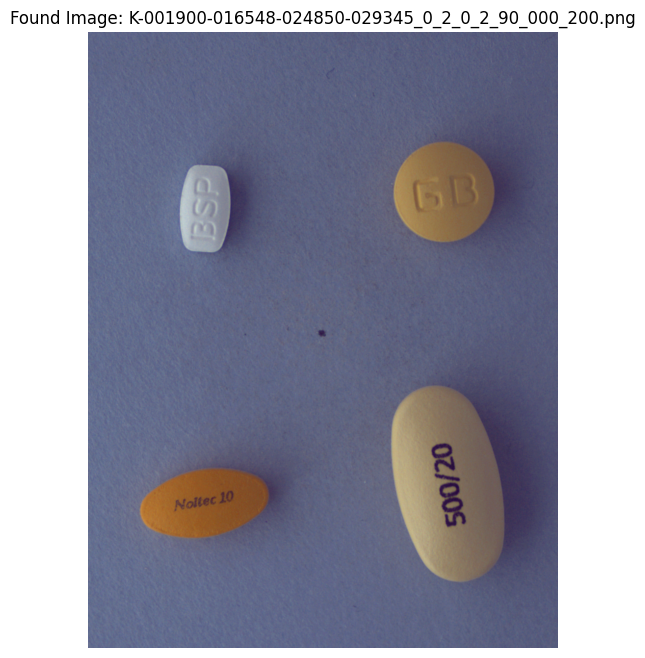

✅ 파일을 찾았습니다: /root/.cache/kagglehub/competitions/ai10-level1-project/sprint_ai_project1_data/train_images/K-001900-016548-024850-029345_0_2_0_2_90_000_200.png


In [15]:

# 사용 예시
show_pill_by_code("024850")

## bbox 이상치 확인

In [31]:
def check_bbox_outliers(json_dir):
    outliers = []
    print(f"🔍 BBox 이상치 탐색 시작: {json_dir}")
    print("-" * 60)

    for filename in os.listdir(json_dir):
        if not filename.endswith('.json'): continue

        full_path = os.path.join(json_dir, filename)
        with open(full_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

            img_obj = data.get("images", [])[0]

            img_w = img_obj.get("width", 976)
            img_h = img_obj.get("height", 1280)



        for idx, ann in enumerate(data.get("annotations", [])):
            bbox = ann.get("bbox", [])
            x, y, w, h = bbox

            reasons = []
            if x < 0 or y < 0: reasons.append(f"음수 좌표(x:{x}, y:{y})")
            if w <= 0 or h <= 0: reasons.append(f"크기 오류(w:{w}, h:{h})")
            if x + w > img_w: reasons.append(f"가로 범위 초과(x+w:{x+w} > {img_w})")
            if y + h > img_h: reasons.append(f"세로 범위 초과(y+h:{y+h} > {img_h})")

            if reasons:
                print(f"🚨 [이상치 발견] 파일: {filename} | 인덱스: {idx} | 사유: {', '.join(reasons)}")

                outliers.append({
                    "file": filename,
                    "image_file": img_obj.get("file_name", filename.replace(".json", ".jpg")),
                    "bbox": bbox,
                    "img_size": (img_w, img_h),
                    "full_ann": ann  # <--- 이 부분만 추가 (원본 객체 보존)
                })

    if not outliers: print("✅ 모든 BBox가 정상 범위 내에 있습니다.")
    return outliers


In [32]:

# 실행
outliers = check_bbox_outliers(output_dir)

🔍 BBox 이상치 탐색 시작: ./merged_labels
------------------------------------------------------------
🚨 [이상치 발견] 파일: K-003351-016262-018357_0_2_0_2_75_000_200.json | 인덱스: 0 | 사유: 가로 범위 초과(x+w:6878 > 976)


In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def show_outlier_image(outlier_item, base_img_path):
    target_file = outlier_item['image_file']
    bbox = outlier_item['bbox']
    img_w, img_h = outlier_item['img_size']

    # 1. 이미지 탐색 및 시각화 (기존 로직 동일)
    img_full_path = None
    for root, dirs, files in os.walk(base_img_path):
        if target_file in files:
            img_full_path = os.path.join(root, target_file)
            break

    if img_full_path:
        img = Image.open(img_full_path)
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.imshow(img)
        rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3],
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.set_xlim(0, max(img_w, bbox[0] + bbox[2] + 100))
        ax.set_ylim(max(img_h, bbox[1] + bbox[3] + 100), 0)
        plt.title(f"Outlier: {target_file}")
        plt.show()

    # 2. Annotation 객체 JSON 출력 (추가된 부분)
    print(f"\n📄 [Raw Annotation Data]")
    print("-" * 60)
    print(json.dumps(outlier_item['full_ann'], indent=4, ensure_ascii=False))
    print("-" * 60)


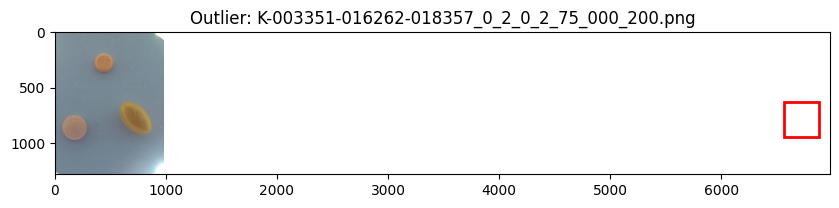


📄 [Raw Annotation Data]
------------------------------------------------------------
{
    "area": 97965,
    "iscrowd": 0,
    "bbox": [
        6567,
        625,
        311,
        315
    ],
    "category_id": 18357,
    "ignore": 0,
    "segmentation": [],
    "id": 903,
    "image_id": 239
}
------------------------------------------------------------


In [38]:
for outlier in outliers:
    show_outlier_image(outlier, train_images_path)

bbox x 좌표 6567 => 567 로 수정 필요